In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import seaborn as sns
from operator import attrgetter

In [2]:
# Load all the data
customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')

In [3]:
# Convert into correct formats
customers = customers.astype({
    'customer_id':'object',
    'customer_unique_id':'object',
    'customer_zip_code_prefix':'int',
    'customer_city':'object',
    'customer_state':'object'
})

order_items = order_items.astype({
    'order_id':'object',
    'order_item_id':'int',
    'product_id':'object',
    'price':'float',
    'freight_value':'float'
})
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

orders = orders.astype({
    'order_id':'object',
    'customer_id':'object',
    'order_status':'object'
})
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


# 1. Monthly Retention

In [7]:
# orders' statuses
orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
# Merge with customer data
orders_customers = pd.merge(orders, customers[['customer_id','customer_unique_id',
                                                         'customer_city','customer_state']], 
                               on = 'customer_id',
                               how='left')

In [ ]:
# Order month
# Use the date of order creation - now (!) we are interested whether clients use our app
# but not how effective we are in processing them
orders_customers['order_period'] = orders_customers['order_purchase_timestamp'].dt.to_period('M')
orders_customers['order_period_day'] = orders_customers['order_purchase_timestamp'].dt.to_period('D')


# Cohort
orders_customers['cohort'] = orders_customers \
        .groupby('customer_unique_id')['order_purchase_timestamp'] \
        .transform('min').dt.to_period('M')
orders_customers['cohort_day'] = orders_customers \
        .groupby('customer_unique_id')['order_purchase_timestamp'] \
        .transform('min').dt.to_period('D')
        
# Period number when customer used the app in months
orders_customers['period_number_month'] = np.floor((orders_customers.order_period_day - 
                                                       orders_customers.cohort_day) \
                                                           .apply(attrgetter('n')) / 30)
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,order_period,order_period_day,cohort,cohort_day,period_number_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10,2017-10-02,2017-09,2017-09-04,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,2018-07,2018-07-24,2018-07,2018-07-24,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2018-08,2018-08-08,2018-08,2018-08-08,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,2017-11,2017-11-18,2017-11,2017-11-18,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,2018-02,2018-02-13,2018-02,2018-02-13,0.0


In [10]:
# Number of customers from each cohort by periods
# Filter out non-delivered orders
df_cohort = orders_customers \
    .query('order_status == "delivered" ') \
    .groupby(['cohort', 'period_number_month']) \
    .agg(n_customers=('customer_unique_id', 'nunique')) \
    .reset_index()
    
# Cohort table
cohort_pivot = df_cohort.pivot_table(index='cohort', 
                                     columns='period_number_month', 
                                     values='n_customers')
cohort_pivot.head(10)

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,718.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1627.0,3.0,3.0,6.0,4.0,2.0,4.0,2.0,2.0,5.0,...,6.0,2.0,3.0,2.0,1.0,2.0,4.0,NaN,NaN,NaN
2017-03,2504.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,7.0,6.0,...,4.0,5.0,3.0,7.0,2.0,3.0,3.0,NaN,NaN,NaN
2017-04,2254.0,8.0,6.0,1.0,7.0,8.0,6.0,10.0,5.0,6.0,...,4.0,NaN,2.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN
2017-05,3452.0,16.0,15.0,11.0,13.0,12.0,12.0,5.0,10.0,9.0,...,11.0,7.0,4.0,9.0,5.0,NaN,NaN,NaN,NaN,NaN
2017-06,3035.0,13.0,14.0,11.0,4.0,15.0,10.0,6.0,4.0,11.0,...,8.0,2.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


Looking at the first several months - it seems like the app was very unstable in the first several months because there were only 4 people who used it in Sep 2016, 321 people in Oct 2016, 0 people in Nov 2016, and 1 person in Dec 2016.

In [11]:
# Cohort size
cohort_size = cohort_pivot.iloc[:, 0]

# Retention
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

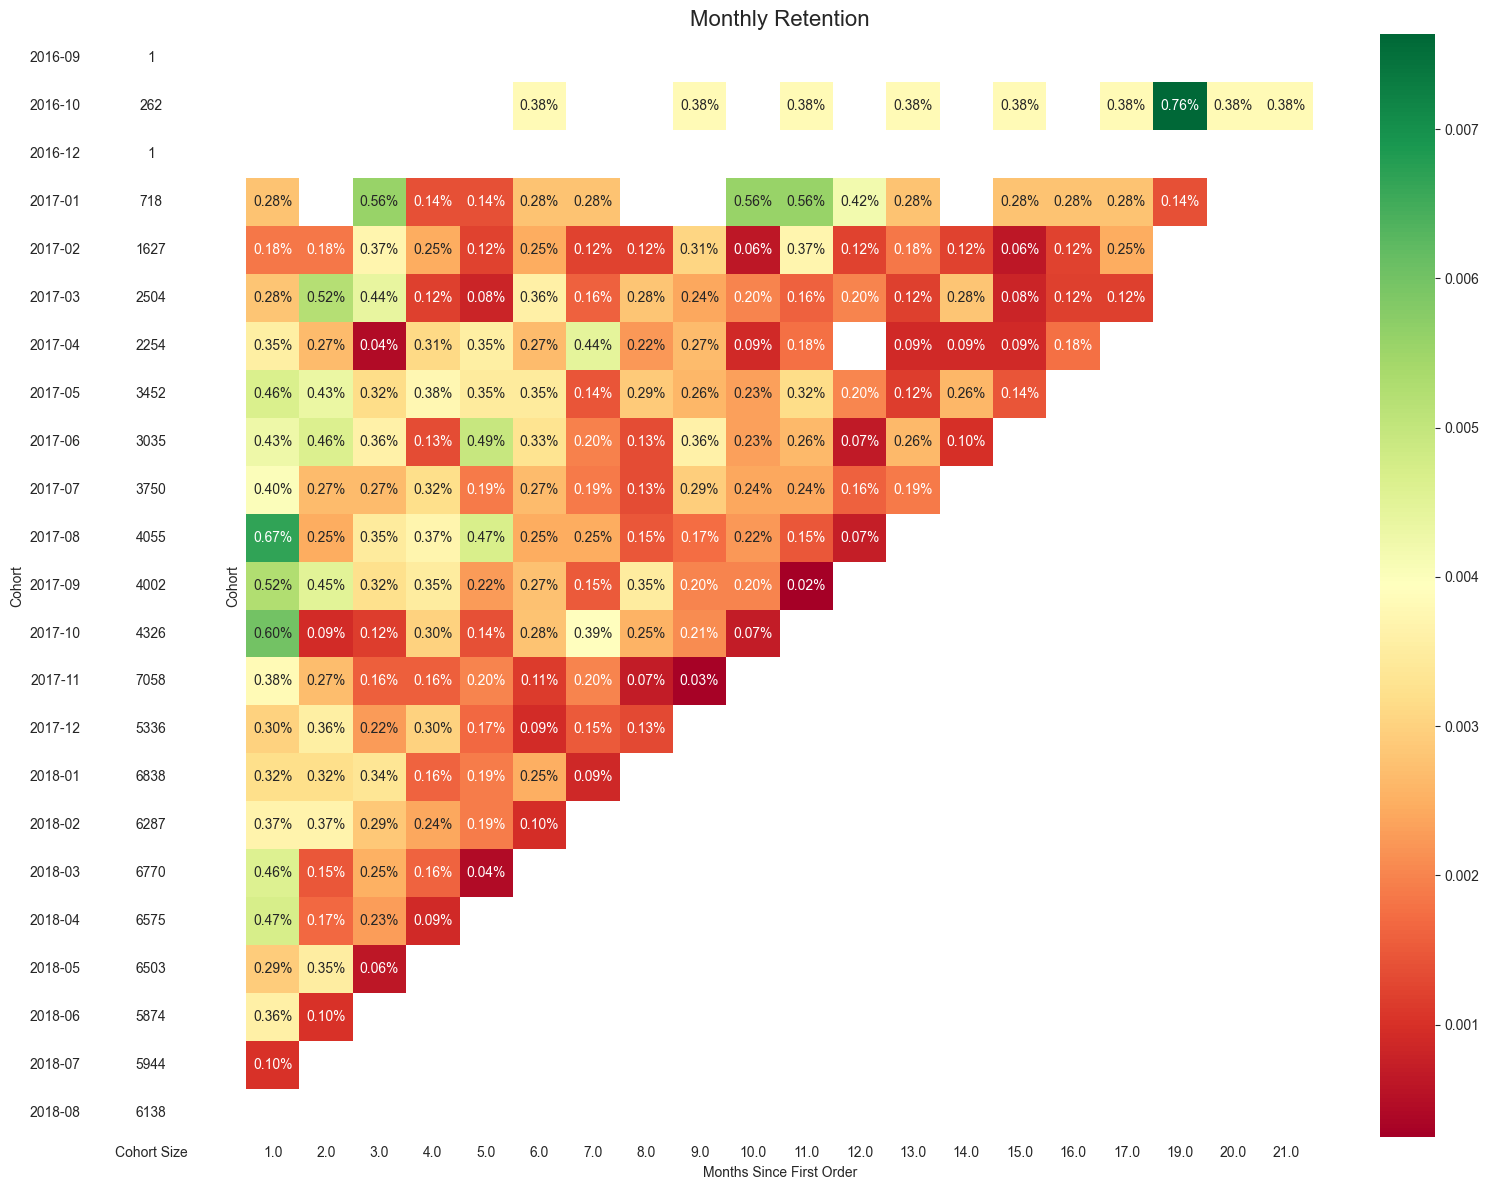

In [12]:
# Heatmap
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), 
                           sharey=True, 
                           gridspec_kw={'width_ratios': [1, 11]})

    # Retention heatmap
    sns.heatmap(retention_matrix.iloc[:,1:],
                mask=retention_matrix.iloc[:,1:].isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='Months Since First Order', ylabel='Cohort')

    # Cohort size heatmap
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'Cohort Size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])
    ax[0].set(ylabel = 'Cohort')

    fig.tight_layout()
    plt.show()

Note that we excluded 0th month (100% retention) for nicer visualization. Retention is very small - even for the 1st month it doesn't exceed 1%.

In [13]:
# Median retention for the 1st month
retention_matrix.iloc[:,1].median() * 100

np.float64(0.3658342611738508)

In [14]:
# Cohort with max 3rd month retention
retention_matrix.iloc[:,3].idxmax()

Period('2017-01', 'M')

In [15]:
# Largest 3-rd month cohort's retention
retention_matrix.iloc[:,3].max() * 100

np.float64(0.5571030640668524)

The monthly retention is very small. The median retention for the first month is only 0.37%. The cohort with the largest third month retention (0.56%) is the Jan 2017 cohort.

# 2. Product-Market Fit

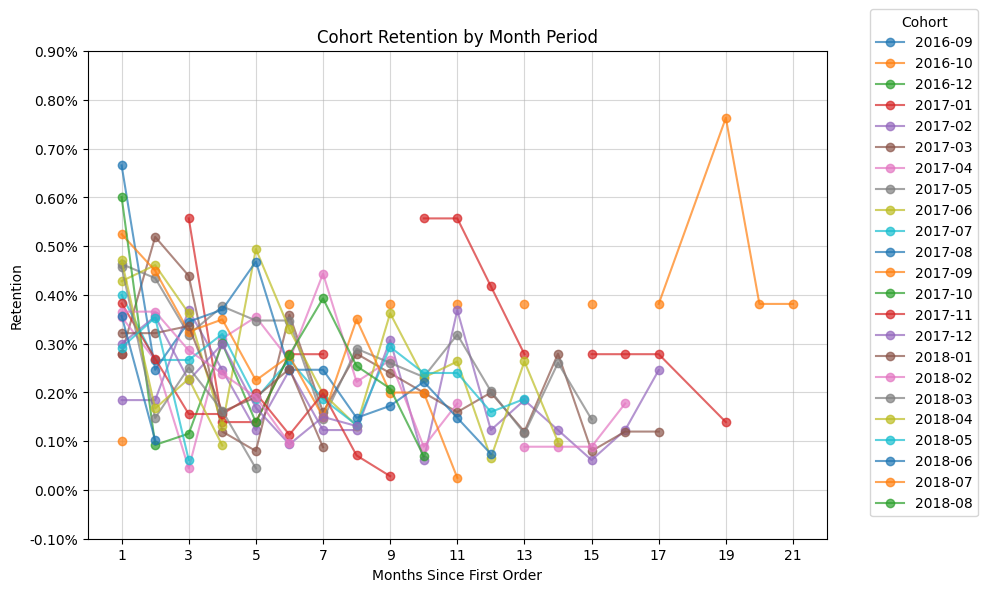

In [16]:
# Retention over the months in different cohorts
fig, ax = plt.subplots(1,1, figsize = (10,6))
data = retention_matrix.iloc[:,1:]
x = data.columns

for cohort in data.index:
    y = data.loc[cohort,:].values * 100
    x = data.columns.astype(int)
    ax.plot(x, y, label=str(cohort), marker='o', alpha=0.7)

vals = plt.gca().get_yticks()
plt.yticks(vals, [f'{v:.2f}%' for v in vals])
plt.xticks(range(1,22,2))

plt.title('Cohort Retention by Month Period')
plt.xlabel('Months Since First Order')
plt.ylabel('Retention')
plt.legend(bbox_to_anchor=(1.05, 1.1), loc='upper left', title = 'Cohort')
plt.grid(True, alpha = 0.5)
plt.tight_layout()
plt.show()

Retention is very small. Less than 1% of clients come back even after 1 month, so there is no product-market fit. To find possible reasons for that, let's take a look at order statuses.

In [112]:
# Proportion of orders with different current statuses by client
order_status_prop_by_id = orders_customers.groupby('customer_unique_id', as_index=False) \
                            .order_status.value_counts(normalize=True)
order_status_prop_by_id.head()

,customer_unique_id,order_status,proportion
0,0000366f3b9a7992bf8c76cfdf3221e2,delivered,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,delivered,1.0
2,0000f46a3911fa3c0805444483337064,delivered,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,delivered,1.0
4,0004aac84e0df4da2b147fca70cf8255,delivered,1.0


  order_status  proportion
0     approved    1.000000
1     canceled    0.933712
2      created    0.900000
3    delivered    0.998969
4     invoiced    0.973992
5   processing    0.973422
6      shipped    0.970735
7  unavailable    0.970158


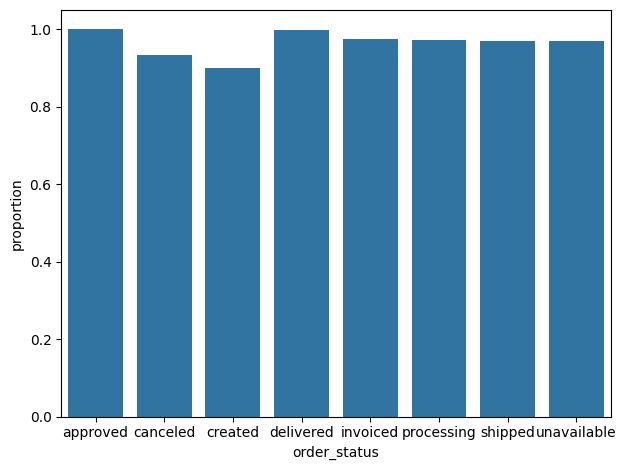

In [113]:
# Mean proportion of current statuses
order_status_prop = order_status_prop_by_id.groupby('order_status',as_index=False).proportion.mean()
print(order_status_prop)
sns.barplot(data = order_status_prop, x = 'order_status', y = 'proportion')
plt.tight_layout()

(Note that all these columns don't have to sum up to 1 because these are mean statuses WITHIN 1 person)

93% of orders from a single client are canceled for some reason and 97% are canceled because items in the order are unavailable. 

It means that many clients cancel practically all their orders. Perhaps it happens when they make their first order - it is canceled for some reason - clients never come back. This may also explain small retention rate.

Let's see how it developed over time: what proportion of all

There might be problems with order deliveries - let's check that.

In [19]:
# Awaiting times

# Time to confirm the payment (in hours)
orders['payment_conf_dur_hours'] = (orders.order_approved_at - orders.order_purchase_timestamp).dt.total_seconds() / 3600

# Time to pass the order to the logistic company (in hours)
orders['pass_to_logistics_dur_hours'] = (orders.order_delivered_carrier_date - 
                                         orders.order_approved_at).dt.total_seconds() / 3600

# Time to deliver the order since the creation of the order (in days)
orders['delivery_dur_days'] = (orders.order_delivered_customer_date - 
                                         orders.order_purchase_timestamp).dt.total_seconds() / (3600*24)

# Difference between actual delivery date and expected (in days)
# Negative values: the order was delivered on time
# Positive values: the order was late
orders['late_delivery_dur_days'] = (orders.order_delivered_customer_date - 
                                         orders.order_estimated_delivery_date).dt.total_seconds() / (3600*24)

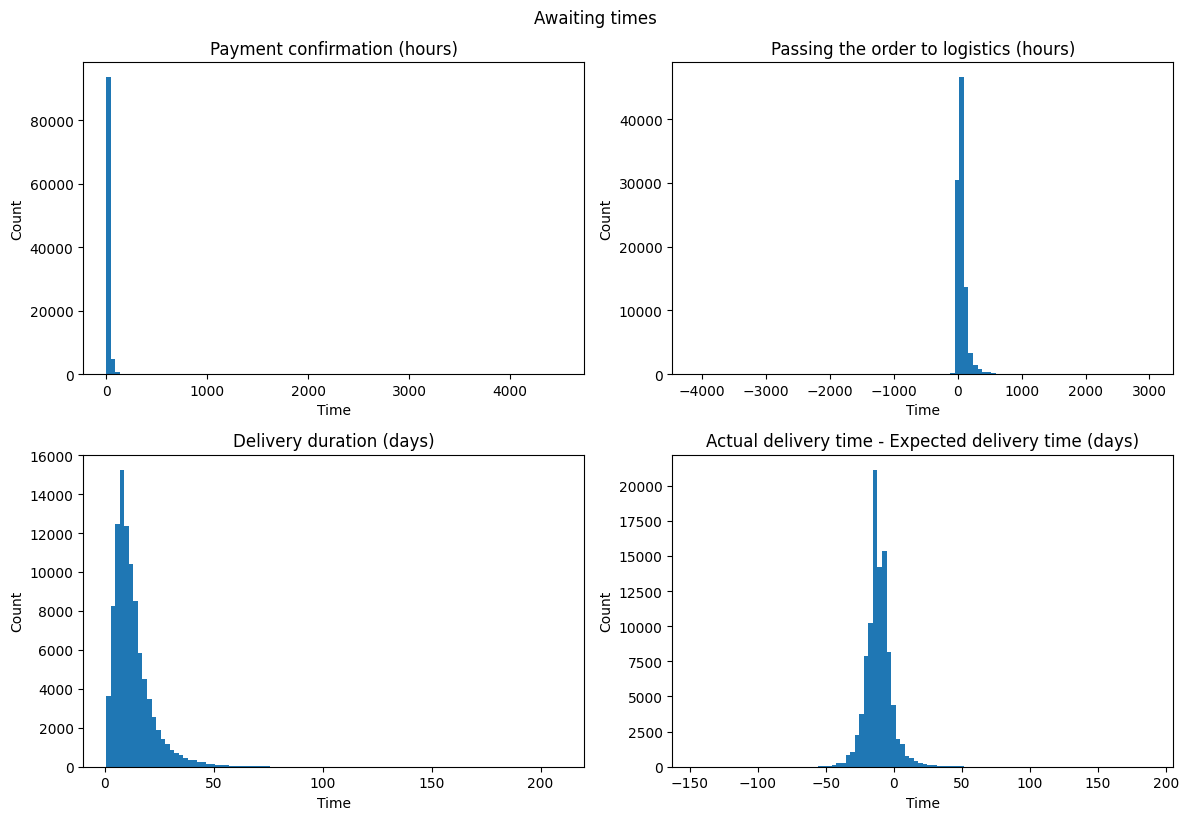

In [20]:
# Visualize awaiting times
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()
dat = orders[['payment_conf_dur_hours','pass_to_logistics_dur_hours',
              'delivery_dur_days','late_delivery_dur_days']]
dur_labels = {'payment_conf_dur_hours':'Payment confirmation (hours)',
              'pass_to_logistics_dur_hours':'Passing the order to logistics (hours)',
              'delivery_dur_days':'Delivery duration (days)',
              'late_delivery_dur_days':'Actual delivery time - Expected delivery time (days)'}

for i, dur in enumerate(dat.columns):
    axes[i].hist(dat[dur], bins = 100)
    axes[i].set_title(dur_labels[dur])
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Awaiting times', x = 0.5, y = 1.02)
plt.show()

In [21]:
# Summary stats
orders[['payment_conf_dur_hours','pass_to_logistics_dur_hours',
              'delivery_dur_days','late_delivery_dur_days']].describe()

,payment_conf_dur_hours,pass_to_logistics_dur_hours,delivery_dur_days,late_delivery_dur_days
count,99281.000000,97644.000000,96476.000000,96476.000000
mean,10.419094,67.320916,12.558702,-11.179120
std,26.038004,85.186249,9.546530,10.186113
min,0.000000,-4109.256111,0.533414,-146.016123
25%,0.215000,21.012222,6.766403,-16.244384
50%,0.343333,43.641528,10.217755,-11.948941
75%,14.580833,85.931250,15.720327,-6.390000
max,4509.180556,3018.301667,209.628611,188.975081


There are many outliers that don't allow good visualization. Let's create plots after excluding outliers (1.5 IQR rule)

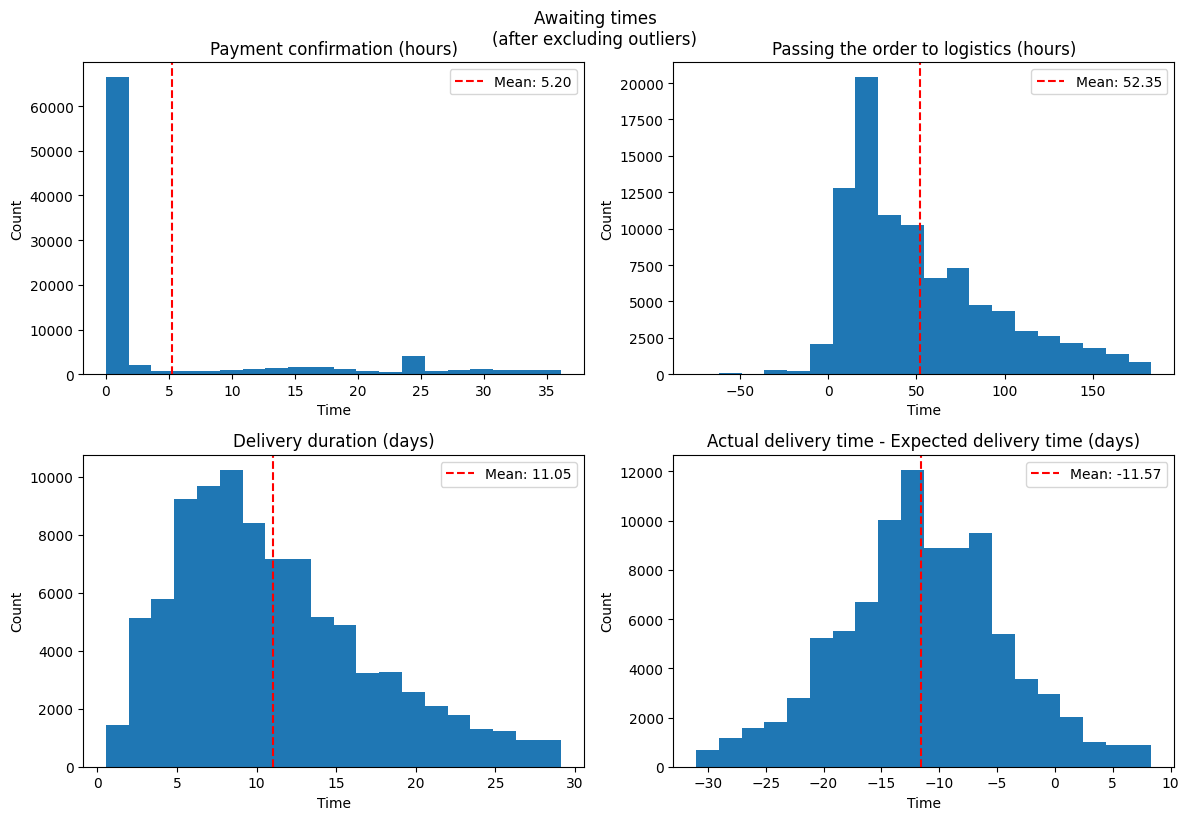

In [22]:
# Visualize awaiting times after excluding outliers
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()
dat = orders[['payment_conf_dur_hours','pass_to_logistics_dur_hours',
              'delivery_dur_days','late_delivery_dur_days']]
dur_labels = {'payment_conf_dur_hours':'Payment confirmation (hours)',
              'pass_to_logistics_dur_hours':'Passing the order to logistics (hours)',
              'delivery_dur_days':'Delivery duration (days)',
              'late_delivery_dur_days':'Actual delivery time - Expected delivery time (days)'}

for i, dur in enumerate(dat.columns):
    x = dat[dur]
    q25, q75 = x.quantile([0.25,0.75])
    iqr = q75 - q25
    upper = q75 + 1.5*iqr
    lower = q25 - 1.5*iqr
    x_clean = x[(x <= upper) & (x >= lower)]
    x_clean_mean = x_clean.mean()
    
    axes[i].hist(x_clean, bins = 20)
    axes[i].axvline(x_clean_mean, ls = '--', color = 'red', 
                    label = f'Mean: {x_clean_mean:.2f}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].set_title(dur_labels[dur])


plt.tight_layout()
plt.suptitle('Awaiting times\n(after excluding outliers)', x = 0.5, y = 1.02)
plt.show()

Even after excluding the outliers, on average, it takes 5.2 hours to confirm the payment, after that it takes 52 hours (more than 2 days) to pass the order to the logistic company - which make total delivery time of 11 days (mostly on time). 

Note that this is the data after cleaning the outliers. In the raw data there is some number of orders that are far off. 

Let's focus specifically on the canceled orders.

In [23]:
canceled_orders = orders.query('order_status=="canceled" | order_status=="unavailable"')

# Select columns
canceled_orders_times = canceled_orders[['order_status','payment_conf_dur_hours','pass_to_logistics_dur_hours',
              'delivery_dur_days','late_delivery_dur_days']]
# Calculate NULLs by order_status
canceled_orders_times_nulls = (canceled_orders_times
 .groupby('order_status')
 .apply(lambda x: x.isnull().sum())
) 


# Proportion of missing values for each of the durations
canceled_orders_times_nulls.divide(canceled_orders_times.groupby('order_status').size(), 
                                   axis=0)

,payment_conf_dur_hours,pass_to_logistics_dur_hours,delivery_dur_days,late_delivery_dur_days
order_status,,,,
canceled,0.2256,0.88,0.9904,0.9904
unavailable,0.0000,1.00,1.0000,1.0000


In [24]:
# Mean durations
canceled_orders_times \
    .groupby('order_status') \
    .apply(lambda x: x.mean())

,payment_conf_dur_hours,pass_to_logistics_dur_hours,delivery_dur_days,late_delivery_dur_days
order_status,,,,
canceled,14.665213,77.418807,20.360006,-27.16341
unavailable,24.388771,NaN,NaN,NaN


For some reason in 23% of canceled orders the payment wasn't confirmed. At the same time the mean time for payment confirmation is 14 hours!

88% of canceled orders were not passed to the logistic company (and the mean is 77 hours). And only 1% of orders was canceled after it was delivered.

100% of unavailable orders were canceled when they had to be passed to the logistic company.

In summary, there is no product-market fit. The retention rate is below 1%. Therefore scaling the product is risky and is not recommended.

A possible reason for small retention can be:

1. Slow payment confirmation process. When ideally it should take several seconds or minutes, currently it takes more than 10 hours.
2. Passing the order to the logistic company takes too long.

The recommendation is to investigate the payment confirmation process (check for potential errors or optimize it) and reduce the time spent for passing the orders to the logistic company.

# 3. Metrics

## GMV 

Gross Merchandise Value indicates the total monthly income - this is the sum of all orders that were sold.

In [25]:
# Merge orders with order items and unique customer ids
orders_full = pd.merge(orders, order_items, on = 'order_id')
orders_full_delivered = orders_full.loc[orders_full['order_status']=='delivered'].copy()
orders_full_delivered = pd.merge(orders_full_delivered,customers[['customer_id','customer_unique_id']],
                                 on = 'customer_id',
                                 how = 'left')
orders_full_delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_conf_dur_hours,pass_to_logistics_dur_hours,delivery_dur_days,late_delivery_dur_days,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,56.795833,8.436574,-7.107488,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,11.109167,13.782037,-5.355729,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,4.910278,9.394213,-17.245498,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,89.900000,13.208750,-12.980069,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,21.434722,2.873877,-9.238171,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6


In [26]:
# Total prices
order_total_price = orders_full_delivered.groupby(['customer_unique_id','order_purchase_timestamp','order_id'], as_index=False)\
        .price.sum()\
        .rename(columns={'price':'total_price'})
order_total_price['month'] = order_total_price['order_purchase_timestamp'].dt.to_period('M')
order_total_price.head()

,customer_unique_id,order_purchase_timestamp,order_id,total_price,month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,e22acc9c116caa3f2b7121bbb380d08e,129.90,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,3594e05a005ac4d06a72673270ef9ec9,18.90,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,b33ec3b699337181488304f362a6b734,69.00,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,41272756ecddd9a9ed0180413cc22fb6,25.99,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,d957021f1127559cd947b62533f484f7,180.00,2017-11


In [27]:
# Monthly GMV
gmv = order_total_price.groupby('month',as_index=False).total_price.sum()
gmv.rename(columns={'total_price':'total_income'}, inplace=True)
gmv['month']=gmv['month'].astype(str)
gmv.head()

,month,total_income
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


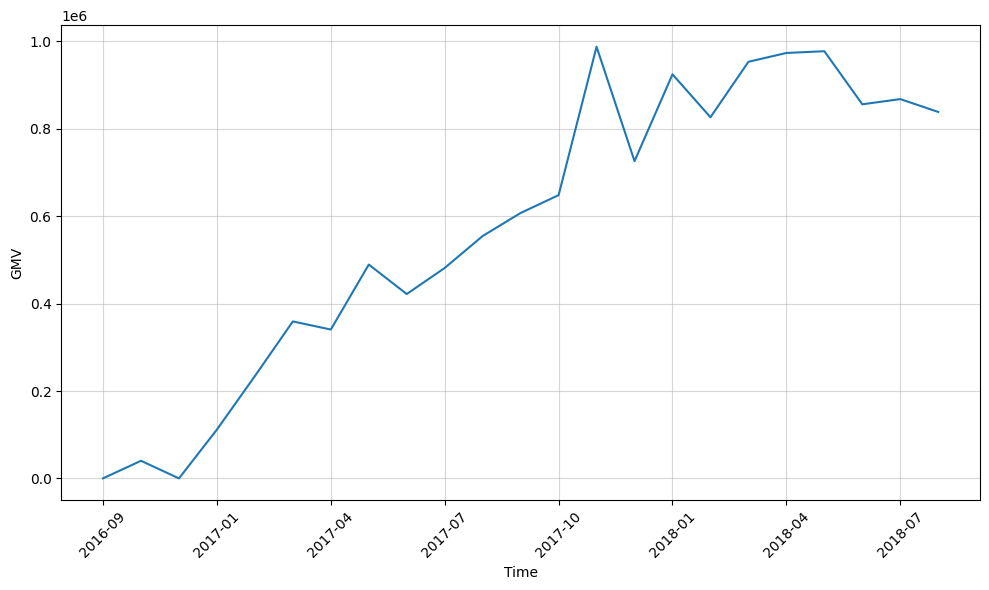

In [28]:
# GMV
plt.figure(figsize=(10,6))
plt.plot(gmv.month,gmv.total_income)
ticks = gmv.month[::3]
plt.xticks(ticks=ticks, labels=ticks, rotation=45)
plt.xlabel('Time')
plt.ylabel('GMV')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

GMV grew over time by the end of 2017, after that GMV has plateaued.

## MAU

Monthly Active Users - the number of unique users that use our app every month.

In [29]:
mau = order_total_price.groupby('month',as_index=False).customer_unique_id.nunique()
mau.rename(columns={'customer_unique_id':'n_unique_customers'}, inplace=True)
mau['month']=mau['month'].astype(str)
mau.head()

,month,n_unique_customers
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,718
4,2017-02,1630


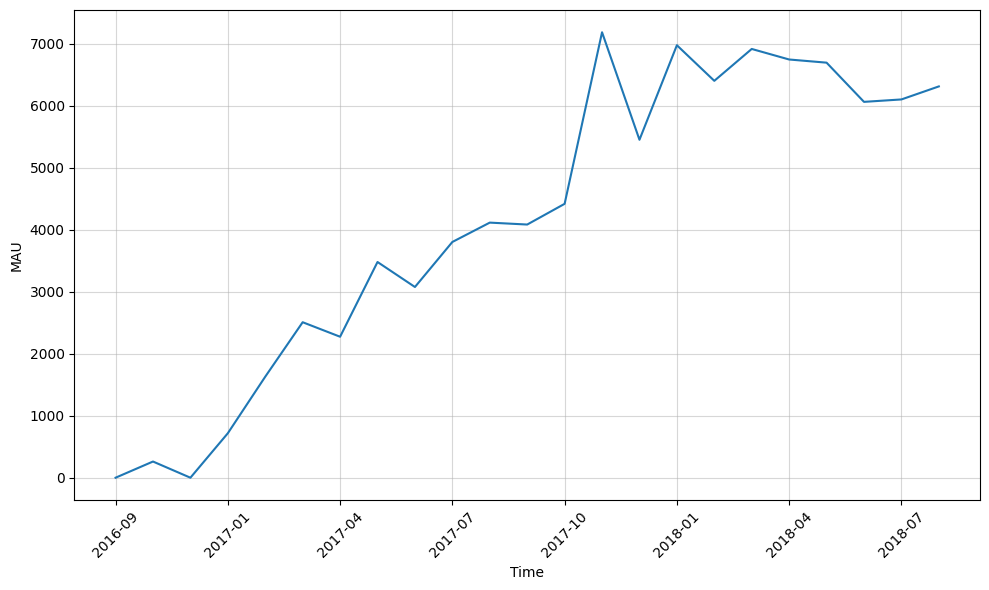

In [30]:
# MAU
plt.figure(figsize=(10,6))
plt.plot(mau.month,mau.n_unique_customers)
ticks = mau.month[::3]
plt.xticks(ticks=ticks, labels=ticks, rotation=45)
plt.xlabel('Time')
plt.ylabel('MAU')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

The number of monthly active users had been growing before the end of 2017, later it has paleaued.

## CR into Paying Customers

Conversion Rate into Paying Customers will show how interested in the app our clients are. We don't have enough data to calculate it (we would also need traffic data - how many customers download the app and what proportion of them make a purchase).

## Retention

Retention will show how likely our subjects are to reuse the app. It was computed above.

As mentioned before, retention rate is extremely small (even the 1st month retention doesn't exceed 1%).

## ARPU

Average Revenue per User = $\frac{GMV}{MAU}$ will show how much money we make on average from a single customer.

In [31]:
arpu = pd.merge(gmv, mau, on = 'month')
arpu['arpu'] = arpu.total_income / arpu.n_unique_customers
arpu.head()

,month,total_income,n_unique_customers,arpu
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337


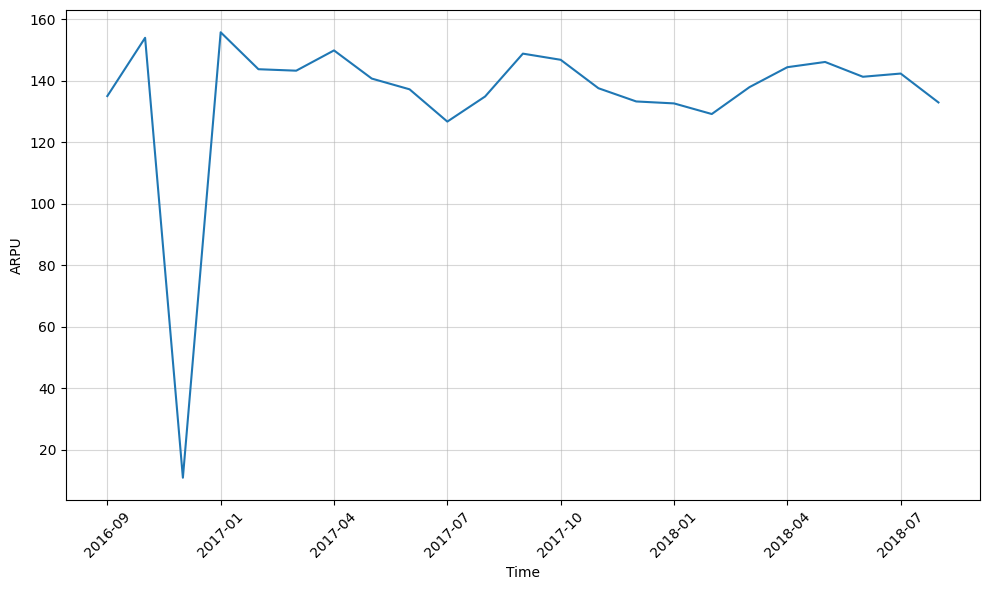

In [32]:
# ARPU
plt.figure(figsize=(10,6))
plt.plot(arpu.month,arpu.arpu)
ticks = arpu.month[::3]
plt.xticks(ticks=ticks, labels=ticks, rotation=45)
plt.xlabel('Time')
plt.ylabel('ARPU')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

There was only 1 customer in Sep and Dec 2016 - so the data is very noisy there. Most likely the app wasn't popular at the time. However, if we believe that it had to be popular at the time, we should investigate for possible bugs in data collection or other errors (e.g. marketing mistakes).

# 4. ICE Metrics

Hypotheses:

1. If we fix the bug in the order processing system, customers will no longer face the problem of order cancellation, resulting in an increase in the number of delivered orders. We assume that this will eliminate all cancellations.

2. If we reduce the time to order shipment, customers will stop receiving their orders with delays, resulting in an increase in the total number of orders driven by repeat purchases.

3. If we introduce a new payment method that converts customers into repeat buyers, customers will no longer experience difficulties when placing an order, resulting in an increase in the total number of orders driven by repeat purchases from those who had never placed a repeat order before.

In [33]:
# Impact scale
impact_scale = pd.DataFrame({
    'lower': [0, 51, 151, 351, 751, 1551, 3151, 6351, 12751, 25551],
    'upper': [50, 150, 350, 750, 1550, 3150, 6350, 12750, 25550, 51150],
    'scaled_impact': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
})
impact_scale

,lower,upper,scaled_impact
0,0,50,1
1,51,150,2
2,151,350,3
3,351,750,4
4,751,1550,5
5,1551,3150,6
6,3151,6350,7
7,6351,12750,8
8,12751,25550,9
9,25551,51150,10


In [34]:
# Hypotheses
hypothesis = pd.DataFrame({
    'hypothesis': [1, 2, 3],
    'confidence': [8, 10, 5],
    'ease': [6, 4, 9]
})
hypothesis

,hypothesis,confidence,ease
0,1,8,6
1,2,10,4
2,3,5,9


In [35]:
# Median retention of the first month
med_ret_1st_month = retention_matrix.iloc[:,1].median()
med_ret_1st_month

np.float64(0.003658342611738508)

## Hypothesis 1

In [36]:
# Data about canceled orders after June 2017
# Do NOT count unavailable orders because they were canceled due to other reasons
canceled_orders_after_2017_06 = canceled_orders.loc[(canceled_orders['order_purchase_timestamp'] >= '2017-06-01') &
                                                    (canceled_orders['order_status'] == 'canceled')]
canceled_orders_after_2017_06.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_conf_dur_hours,pass_to_logistics_dur_hours,delivery_dur_days,late_delivery_dur_days
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14,61.683056,NaN,NaN,NaN
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22,0.408611,72.579444,NaN,NaN
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaT,2018-02-23,0.265556,31.866111,NaN,NaN
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,NaN,NaN,NaN,NaN
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17,NaN,NaN,NaN,NaN


We expect that all canceled orders would be delivered. Plus some customers (based on the retention rate) would return to our app and create a second order. That's why 

$\text{Impact}_{H1} = N_{\text{canceled orders}} \times (1 + \text{Retention})$ 

In [37]:
# Impact of H1
impact1 = canceled_orders_after_2017_06.shape[0] * (1 + med_ret_1st_month)
impact1

np.float64(500.8255129632575)

## Hypothesis 2

In [38]:
# Orders that arrived late
late_orders = orders.loc[(orders['order_purchase_timestamp'] >= '2017-06-01') &
                         (orders['late_delivery_dur_days'] > 0)]
late_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_conf_dur_hours,pass_to_logistics_dur_hours,delivery_dur_days,late_delivery_dur_days
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,13.544167,421.765000,21.327963,11.933171
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,26.731389,115.910000,28.928484,9.919375
35,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20,0.263333,78.806111,30.374757,0.041262
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,2.889167,452.882222,33.896933,7.791238
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,0.840000,128.844444,24.943414,1.561644


In [39]:
# Number of orders by order status
late_orders.order_status.value_counts()

order_status
delivered    7295
canceled        1
Name: count, dtype: int64

Ideally, if the hypothesis holds true, we would receive profit from those who canceled the order. Plus some of our clients (based on the retention rate) will come back, so we'd need to multiplu all of them by the retention. That's why:

$\text{Impact}_{H2} = N_{\text{delivered orders}} * \text{Retention} + N_{\text{canceled orders}} \times (1 + \text{Retention})$ 


In [40]:
# Impact of H2
impact2 = sum(late_orders.order_status.value_counts() * [med_ret_1st_month, 1+med_ret_1st_month])
impact2

27.691267695244157

## Hypothesis 3

In [41]:
# Available orders after June 2017
available_orders_after_jun2017 = orders_customers \
    .loc[(orders_customers['order_purchase_timestamp'] >= '2017-06-01') &
         (orders_customers['order_status'] != 'unavailable')]

# Customers with only 1 order
customers_w_1order = available_orders_after_jun2017.groupby('customer_unique_id').order_id.count()
customers_w_1order = customers_w_1order.loc[customers_w_1order==1]

# Available orders from clients who made only 1 order
avail_1order_after_jun2017 = available_orders_after_jun2017.loc[
    available_orders_after_jun2017['customer_unique_id'].isin(customers_w_1order.index)
    ]
avail_1order_after_jun2017.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,order_period,order_period_day,cohort,cohort_day,period_number_month
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,2018-07,2018-07-24,2018-07,2018-07-24,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2018-08,2018-08-08,2018-08,2018-08-08,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,2017-11,2017-11-18,2017-11,2017-11-18,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,2018-02,2018-02-13,2018-02,2018-02-13,0.0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,2017-07,2017-07-09,2017-07,2017-07-09,0.0


In [42]:
# Number of orders by order status
n_orders_by_status_h3 = avail_1order_after_jun2017.order_status.value_counts()
n_orders_by_status_h3

order_status
delivered     80437
shipped         858
canceled        416
invoiced        226
processing      196
created           4
Name: count, dtype: int64

Similar logic as in H2 - some of those clients who already made an order will do it again, and those who canceled wouldn't have cancelled it if there was another payment method plus some of them will make another order:

$\text{Impact}_{H3} = N_{\text{NON-canceled orders}} * \text{Retention} + N_{\text{canceled orders}} \times (1 + \text{Retention})$ 

In [43]:
# Number of canceled and non canceled orders
h3_n_non_canceled = n_orders_by_status_h3.loc[n_orders_by_status_h3.index != 'canceled'].sum()
h3_n_canceled = n_orders_by_status_h3.loc[n_orders_by_status_h3.index == 'canceled']

# Impact of H3
impact3 = h3_n_non_canceled * med_ret_1st_month + h3_n_canceled * (1 + med_ret_1st_month)
impact3 = impact3.values[0] # convert pd Series to np float
impact3

np.float64(716.4852871003659)

## Compute ICE

In [53]:
# Scale impacts
h1_scaled = impact_scale.loc[(impact1 >= impact_scale.lower) & 
                             (impact1 <= impact_scale.upper), 'scaled_impact'] \
                                 .values[0]
h2_scaled = impact_scale.loc[(impact2 >= impact_scale.lower) & 
                             (impact2 <= impact_scale.upper), 'scaled_impact'] \
                                 .values[0]
h3_scaled = impact_scale.loc[(impact3 >= impact_scale.lower) & 
                             (impact3 <= impact_scale.upper), 'scaled_impact'] \
                                 .values[0]

# Add to the data set
hypothesis['impact'] = h1_scaled, h2_scaled, h3_scaled

# Compute ICE
hypothesis['ice'] = hypothesis.apply(
    lambda row: row['confidence'] * row['ease'] * row['impact'], 
    axis = 1)
hypothesis

,hypothesis,confidence,ease,impact,ice
0,1,8,6,4,192
1,2,10,4,1,40
2,3,5,9,4,180


The first hypothesis shows the largest ICE results, so we should prioritize it.

# 5. New Metrics

New metrics that will help track the hypothesis:

- Target metric: cancelation rate = $\frac{\text{Canceled}}{Total}$ will show what proportion of all orders was canceled

- Proxi metric: delivered rate = $\frac{\text{Delivered}}{Total}$ will show what proportion of all orders has been delivered. Though might be even slower than the target metric but it will still represent whether our hypothesis has worked

- Guardrail metric: number of contacts to support service (it is beter to normalize it by the number of orders) = $\frac{\text{Support Contacts}}{Total Orders}$ will increase if we crushed something

To faster track the changes (especially during the experiment), we can use weekly time windows.

Here there is no data related to the number of calls to the support service, but the first two can be visualized

In [71]:
# Cancelation rate
orders_customers['week_order_created'] = orders_customers.order_purchase_timestamp.dt.to_period('W')
metric_rate = (orders_customers
    .groupby('week_order_created')
    .agg(
        total_orders=('order_id', 'count'),
        canceled_orders=('order_status', lambda x: (x == 'canceled').sum()),
        delivered_orders=('order_status', lambda x: (x == 'delivered').sum())
    )
    .assign(
        cancellation_rate=lambda x: x['canceled_orders'] / x['total_orders'],
        delivered_rate=lambda x: x['delivered_orders'] / x['total_orders']
        )
    .reset_index()
)
metric_rate['week_order_created'] = metric_rate['week_order_created'].astype(str)
metric_rate.head()

,week_order_created,total_orders,canceled_orders,delivered_orders,cancellation_rate,delivered_rate
0,2016-08-29/2016-09-04,1,0,0,0.000000,0.000000
1,2016-09-05/2016-09-11,1,1,0,1.000000,0.000000
2,2016-09-12/2016-09-18,2,1,1,0.500000,0.500000
3,2016-09-26/2016-10-02,1,1,0,1.000000,0.000000
4,2016-10-03/2016-10-09,283,20,231,0.070671,0.816254


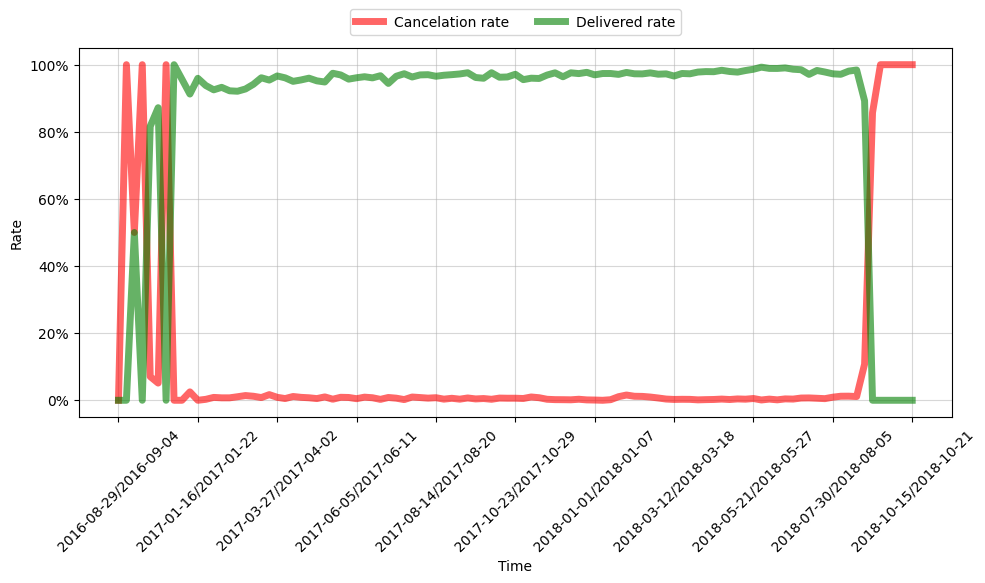

In [ ]:
plt.figure(figsize=(10,6))

# Cancelation rate
plt.plot(metric_rate.week_order_created, metric_rate.cancellation_rate,
         color = 'red', linewidth = 5, alpha = 0.6, label = 'Cancelation rate')
# Delivered rate
plt.plot(metric_rate.week_order_created, metric_rate.delivered_rate,
         color = 'green', linewidth = 5, alpha = 0.6, label = 'Delivered rate')

ticks = metric_rate.week_order_created[::10]
plt.xticks(ticks=ticks, labels=ticks, rotation=45)
ticks = np.arange(0,1.1,0.2).round(2).tolist()
ticks_labels = [f'{t:.0%}' for t in ticks]
plt.yticks(ticks=ticks, labels = ticks_labels)

plt.xlabel('Time')
plt.ylabel('Rate')
plt.legend(bbox_to_anchor = (0.5, 1.07), loc='center', ncol = 2)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Final Report

Report for the Product Manager

---

## Problem Statement

The marketplace has been experiencing revenue stagnation for several months. To understand the root causes and identify growth opportunities, an analysis of order, customer, and product data was conducted covering the period from September 2016 to August 2018.

---

## Key Findings

**Task 1 — Cohort Analysis (Retention):**
Retention across all cohorts drops below 1% by the first month and never stabilizes. Median M1 retention is approximately 0.37%. No cohort shows a "plateau" — the hallmark of a loyal audience.

**Task 2 — Product/Market Fit:**
PMF is absent. Retention is significantly below the threshold values for a marketplace (5–10% at M3+). A likely contributing factor is slow payment confirmation (averaging over 10 hours).

**Task 3 — Key Metrics:**
Five tracking metrics were identified: GMV (revenue), MAU (active users), Conversion Rate (new customer interest — insufficient data to calculate), M1 Retention (engagement), and ARPU (monetization). GMV and MAU are growing, but ARPU and Retention remain low, indicating ongoing customer retention issues.

**Task 4 — Hypothesis Prioritization via ICE:**
Three hypotheses were evaluated. Hypothesis 1 (fixing a processing bug) received the highest ICE score (192), ahead of Hypothesis 3 (180) and Hypothesis 2 (40).

**Task 5 — Metrics for the A/B Test (Hypothesis 1):**
- **Primary:** Cancellation Rate (share of cancelled orders) — should decrease
- **Proxy:** Share of delivered orders — should increase
- **Guardrail:** Support Ticket Rate (support contacts per order) — must not increase; GMV — must not decline

---

## Recommendations

1. **Priority #1 — fix the order processing bug.** This will deliver the greatest short-term impact (ICE = 192) and directly reduce cancellations, which are currently costing the platform potential customers.

2. **Run an A/B test** after the bug fix, tracking Cancellation Rate and share of delivered orders as the primary metrics.

3. **Do not scale to new markets** until PMF is achieved — with retention currently below 1%, expansion carries a high risk of losses.

4. **Separately investigate** order handoff time to logistics (averaging ~67 hours) — this is a distinct issue affecting customer satisfaction and indirectly impacting retention.